In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

energy = pd.read_csv("/kaggle/input/datasets/andrejkorosec8/osupr-moj-projekt/API_EG.USE.ELEC.KH.PC_DS2_en_csv_v2_1880.csv", skiprows=4)
gdp = pd.read_csv("/kaggle/input/datasets/andrejkorosec8/osupr-moj-projekt/API_NY.GDP.PCAP.CD_DS2_en_csv_v2_174336.csv", skiprows=4)
population = pd.read_csv("/kaggle/input/datasets/andrejkorosec8/osupr-moj-projekt/API_SP.POP.TOTL_DS2_en_csv_v2_174326.csv", skiprows=4)
urban = pd.read_csv("/kaggle/input/datasets/andrejkorosec8/osupr-moj-projekt/API_SP.URB.TOTL.IN.ZS_DS2_en_csv_v2_174280.csv", skiprows=4)

print(energy.head())

                  Country Name Country Code  \
0                        Aruba          ABW   
1  Africa Eastern and Southern          AFE   
2                  Afghanistan          AFG   
3   Africa Western and Central          AFW   
4                       Angola          AGO   

                                Indicator Name     Indicator Code  1960  1961  \
0  Electric power consumption (kWh per capita)  EG.USE.ELEC.KH.PC   NaN   NaN   
1  Electric power consumption (kWh per capita)  EG.USE.ELEC.KH.PC   NaN   NaN   
2  Electric power consumption (kWh per capita)  EG.USE.ELEC.KH.PC   NaN   NaN   
3  Electric power consumption (kWh per capita)  EG.USE.ELEC.KH.PC   NaN   NaN   
4  Electric power consumption (kWh per capita)  EG.USE.ELEC.KH.PC   NaN   NaN   

   1962  1963  1964  1965  ...        2016        2017        2018  \
0   NaN   NaN   NaN   NaN  ...         NaN         NaN         NaN   
1   NaN   NaN   NaN   NaN  ...  568.703452  566.073368  568.141299   
2   NaN   NaN   NaN 

In [2]:
energy = energy[energy["Country Name"] == "Slovenia"]
gdp = gdp[gdp["Country Name"] == "Slovenia"]
population = population[population["Country Name"] == "Slovenia"]
urban = urban[urban["Country Name"] == "Slovenia"]

print(energy.head())

    Country Name Country Code                               Indicator Name  \
222     Slovenia          SVN  Electric power consumption (kWh per capita)   

        Indicator Code  1960  1961  1962  1963  1964  1965  ...         2016  \
222  EG.USE.ELEC.KH.PC   NaN   NaN   NaN   NaN   NaN   NaN  ...  6996.467868   

           2017         2018         2019         2020         2021  \
222  7218.87661  7206.250657  7145.713075  6820.238972  7006.378793   

            2022         2023  2024  Unnamed: 69  
222  6731.291866  6418.415618   NaN          NaN  

[1 rows x 70 columns]


In [3]:
years = [str(year) for year in range(1990, 2023)]

energy = energy[years].T
gdp = gdp[years].T
population = population[years].T
urban = urban[years].T

print(energy.head())

              222
1990  5334.905446
1991  5087.452468
1992  4943.155465
1993  4950.932498
1994  5240.160186


Tabela za Slovenijo

In [4]:
data = pd.DataFrame({
    "Energy_kWh_pc": energy.squeeze(),
    "GDP_pc": gdp.squeeze(),
    "Population": population.squeeze(),
    "Urban_%": urban.squeeze()
})

data.index = years
data = data.astype(float)

data.head()

,Energy_kWh_pc,GDP_pc,Population,Urban_%
1990,5334.905446,9925.140710,1998161.0,50.583561
1991,5087.452468,7229.311498,1999429.0,50.527097
1992,4943.155465,7151.152438,1996498.0,50.663132
1993,4950.932498,7254.588874,1991746.0,50.357201
1994,5240.160186,8243.898955,1989443.0,50.175529


## Exploratory Data Analysis (EDA)

The descriptive statistics below summarize the socioeconomic and energy-related variables for Slovenia between 1990 and 2022.

In [5]:
data.describe()

,Energy_kWh_pc,GDP_pc,Population,Urban_%
count,33.000000,33.000000,3.300000e+01,33.000000
mean,6308.769425,17865.290585,2.027862e+06,51.525043
std,762.321482,7327.806384,4.138698e+04,1.990492
min,4943.155465,7151.152438,1.981629e+06,49.761948
25%,5574.706466,10738.088761,1.992060e+06,50.357201
50%,6719.461160,19563.005059,2.006868e+06,50.602421
75%,6917.860467,24013.068206,2.061980e+06,50.983471
max,7218.876610,29192.840193,2.112076e+06,55.452328


In [6]:
correlation_matrix = data.corr()
print(correlation_matrix)

               Energy_kWh_pc    GDP_pc  Population   Urban_%
Energy_kWh_pc       1.000000  0.867746    0.679109  0.509829
GDP_pc              0.867746  1.000000    0.861728  0.541877
Population          0.679109  0.861728    1.000000  0.768579
Urban_%             0.509829  0.541877    0.768579  1.000000


Vidimo, da so podatki dobro kolerirani med seboj, predvsem Energy_kWh_pc in GDP_pc, kar kaže kako je poraba električne energije povezana z razvitostjo države. 


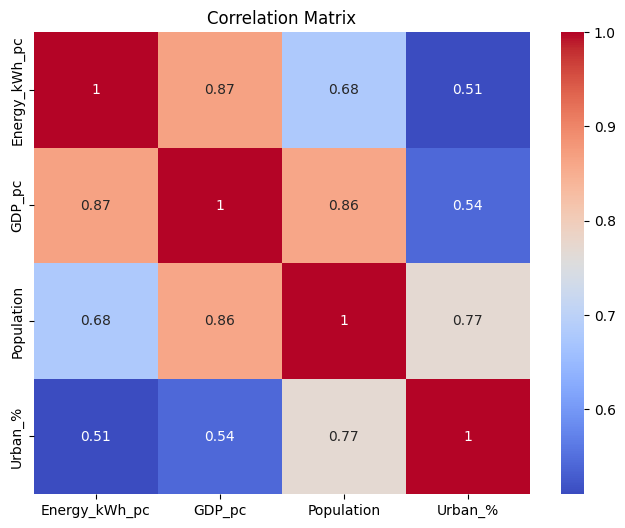

In [7]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm")

plt.title("Correlation Matrix")
plt.show()

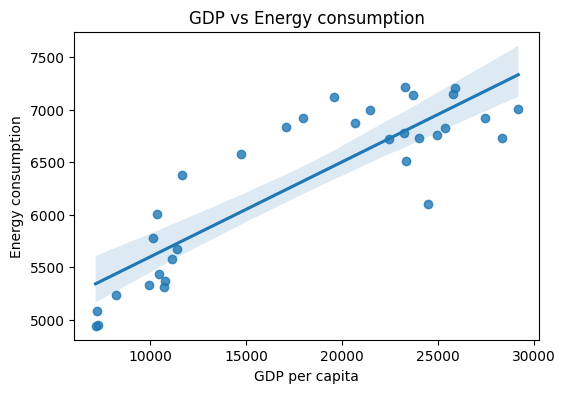

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.regplot(
    x=data["GDP_pc"],
    y=data["Energy_kWh_pc"]
)

plt.xlabel("GDP per capita")
plt.ylabel("Energy consumption")
plt.title("GDP vs Energy consumption")

plt.show()

Ta graf prikazuje povezavo med skupnim številom prebivalcev in porabo električne energije na prebivalca. Opazimo zmerno pozitivno povezavo, kar pomeni, da večje število prebivalcev običajno sovpada z višjo porabo električne energije.

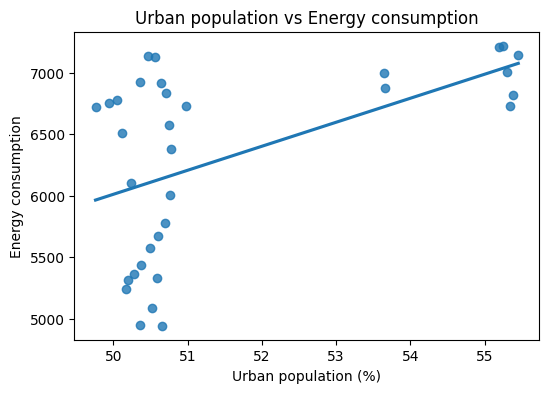

In [9]:
plt.figure(figsize=(6,4))

sns.regplot(
    x=data["Urban_%"],
    y=data["Energy_kWh_pc"],
    ci=None
)

plt.xlabel("Urban population (%)")
plt.ylabel("Energy consumption")
plt.title("Urban population vs Energy consumption")

plt.show()

Graf prikazuje odnos med deležem urbanega prebivalstva in porabo električne energije. Vidna je zmerna pozitivna povezava, kar nakazuje, da urbanizacija vpliva na rast porabe energije, vendar manj izrazito kot gospodarska razvitost. Dejstvo je da se samo število prebivalstva ni toliko povečalo ampak je spremenljivka ševedno pomembna ker gledamo porabo/prebivalca.

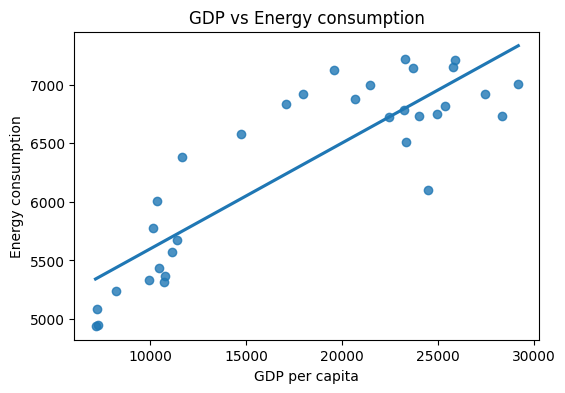

In [10]:
plt.figure(figsize=(6,4))

sns.regplot(
    x=data["GDP_pc"],
    y=data["Energy_kWh_pc"],
    ci=None
)

plt.xlabel("GDP per capita")
plt.ylabel("Energy consumption")
plt.title("GDP vs Energy consumption")

plt.show()

Graf prikazuje močno pozitivno povezavo med bruto domačim proizvodom na prebivalca in porabo električne energije. Višji GDP per capita je povezan z večjo porabo energije, kar kaže na vpliv gospodarske razvitosti in življenjskega standarda na energetske potrebe.

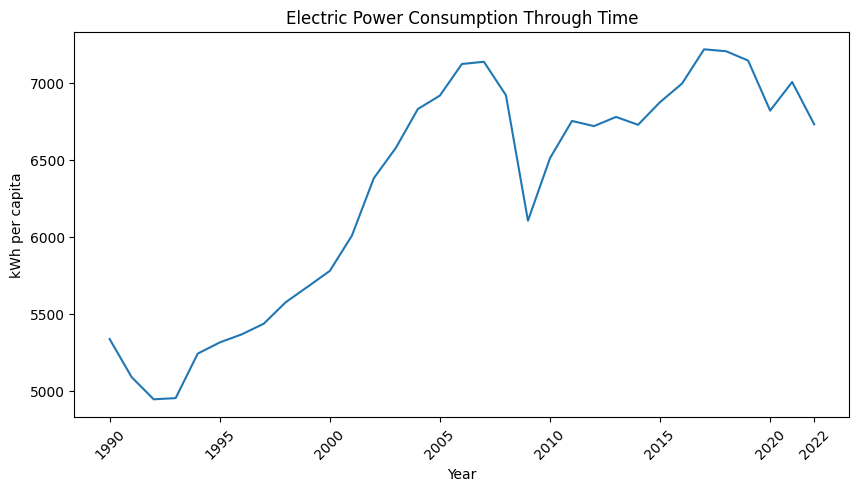

In [11]:
data["Energy_kWh_pc"].plot(figsize=(10,5))

plt.title("Electric Power Consumption Through Time")
plt.ylabel("kWh per capita")
plt.xlabel("Year")

ticks = list(range(0, len(data.index), 5))

if ticks[-1] != len(data.index) - 1:
    ticks.append(len(data.index) - 1)

plt.xticks(ticks, data.index[ticks], rotation=45)

plt.show()

Na grafu je jasno prikazan trend porabe električne energije skozi čas. Opazen je upad porabe v obdobju svetovne finančne krize, kar nakazuje, da imajo lahko gospodarske in geopolitične krize pomemben vpliv na porabo energije. Takšni dogodki vključujejo finančne nestabilnosti, vojne ter druge globalne motnje. Prav tako je opaziti prekinitev pozitivnega trenda rasti porabe energije okoli leta 2019, kar je povezano z začetkom zdravstvene krize COVID-19. Ker prihodnjih kriz in njihovih vplivov ni mogoče zanesljivo napovedati, jih model ne bo posebej upošteval. Napovedovanje bo zato temeljilo na predpostavki stabilnega razvoja brez večjih globalnih kriz.